# Evaluation - Comparing CGAN and Conditional Diffusion 

## Plan

1. Understand how to measure the quality and diversity of generated data using **FID**.  
2. Compare **cGAN vs Diffusion** outputs visually and statistically.  
3. Train a downstream **handwriting classifier** using synthetic data.  
4. Assess which generative approach produces more *useful* data for CAPTCHA robustness.



### Objectives to check
+ Do the samples look human like 
+ we would measure the quantititative quality using Frechet Inception Distance 
+ Also work on using sythetic data from each model to train a useful classifier

In [32]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import inception_v3
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, sys
from scipy import linalg


from utils.visualize import show_batch
from utils.checkpoint import load_checkpoint
from torchmetrics.image.fid import FrechetInceptionDistance

We’ll now load both trained models — the **cGAN** and **Diffusion** generators —  
and use them to generate a fixed number of samples for evaluation.

In [33]:
from model.cgan import Generator
from model.diffusion import ConditionalUNet
from training.train_diffusion import sample_images
from training.train_diffusion import linear_beta_schedule

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f" Using device: {device}")



 Using device: cuda


In [34]:
# Helper Functions

from torchvision import datasets, transforms
def get_real_examples_per_class(n_classes=10):
    """
    Deterministically extracts one MNIST image per class (0–9)
    directly from the dataset without shuffle.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    mnist = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

    imgs, labels = [], []
    for cls in range(n_classes):
        for i in range(len(mnist)):
            if mnist[i][1] == cls:
                imgs.append(mnist[i][0])
                labels.append(cls)
                break  # stop at first match
    return torch.stack(imgs), torch.tensor(labels)




def get_representative_images(imgs, labels, n_classes=10):
    """
    Returns one representative image per class label (0–9).
    Ensures true label alignment for real datasets.
    """
    reps = []
    for i in range(n_classes):
        idx = (labels == i).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            reps.append(imgs[idx[0]])
        else:
            reps.append(torch.zeros_like(imgs[0]))  
    return torch.stack(reps)


@torch.no_grad()
def generate_conditioned_samples_cgan(generator, z_dim=100, device="cuda", n_classes=10):
    """
    Generate one representative sample per class (0–9) from cGAN.
    """
    generator.eval()
    zs = torch.randn(n_classes, z_dim, device=device)
    ys = torch.arange(n_classes, dtype=torch.long, device=device)
    imgs = generator(zs, ys).cpu()
    return imgs, ys.cpu()


@torch.no_grad()
def generate_conditioned_samples_diffusion(
    model,
    device="cuda",
    n_classes=10,
    timesteps=200,          # used same as training
    img_size=(1, 28, 28)
):
    """
    Generate one representative diffusion sample per class (0–9), 
    using the same sampling logic as training-time generation.
    """
    from training.train_diffusion import linear_beta_schedule
    model.eval()

    betas = linear_beta_schedule(timesteps).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, 0)

    imgs_list, labels_list = [], []

    for cls in range(n_classes):
        # Conditioning label for this class
        labels = torch.full((1,), cls, dtype=torch.long, device=device)
        imgs = torch.randn(1, *img_size).to(device)

        # Reverse diffusion loop (same as training sampler)
        for t in reversed(range(timesteps)):
            t_tensor = torch.full((1,), t, device=device, dtype=torch.long)
            pred_noise = model(imgs, t_tensor, labels)
            alpha = alphas[t]
            alpha_bar = alphas_cumprod[t]

            # Predict next sample
            noise = torch.randn_like(imgs) if t > 0 else torch.zeros_like(imgs)
            imgs = (1 / torch.sqrt(alpha)) * (
                imgs - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * pred_noise
            ) + torch.sqrt(betas[t]) * noise

        imgs_list.append(imgs[0].cpu())
        labels_list.append(cls)

    imgs_tensor = torch.stack(imgs_list)
    labels_tensor = torch.tensor(labels_list)
    return imgs_tensor, labels_tensor


def plot_real_cgan_diffusion(real_imgs, cgan_imgs, diff_imgs, n_classes=10):
    """
    Visual comparison between Real, cGAN, and Diffusion images.
   
    """

    fig, axs = plt.subplots(3, n_classes, figsize=(12, 4))
    fig.suptitle(" Comparison: Real vs cGAN vs Diffusion", fontsize=14, fontweight="bold")

    row_titles = [
        "Ground Truth",
        "CGAN",
        "Diffusion"
    ]
    row_colors = ["green", "royalblue", "darkorange"]

    # Plot each row
    for row_idx, row_imgs in enumerate([real_imgs, cgan_imgs, diff_imgs]):
        for i in range(n_classes):
            axs[row_idx, i].imshow(row_imgs[i].squeeze(), cmap="gray")
            axs[row_idx, i].axis("off")
            axs[row_idx, i].set_title(f"Class {i}", fontsize=8, pad=2)

    # Manually place row labels on figure (not as axis labels)
    for idx, (title, color) in enumerate(zip(row_titles, row_colors)):
        fig.text(
            0.02,                                   # x-position (left margin)
            0.84 - idx * 0.32,                      # y-position per row
            title,
            fontsize=11,
            color=color,
            fontweight="bold",
            va="center"
        )

    plt.subplots_adjust(left=0.12, right=0.98, top=0.9, bottom=0.05, hspace=0.3)
    plt.show()

In [35]:


def compute_fid(real_imgs, fake_imgs, device="cuda", batch_size=128):
    """
    Compute FID safely in GPU batches to prevent OOM.
    Works with TorchMetrics' FrechetInceptionDistance.
    """
    fid = FrechetInceptionDistance(normalize=True).to(device)
    fid.reset()

    def batched_update(imgs, real_flag):
        for i in tqdm(range(0, imgs.size(0), batch_size), desc=f"FID {'real' if real_flag else 'fake'}"):
            batch = imgs[i:i + batch_size].to(device, non_blocking=True)
            fid.update(batch, real=real_flag)
            torch.cuda.empty_cache()


    real_imgs_rgb = (real_imgs.repeat(1, 3, 1, 1) + 1) / 2
    fake_imgs_rgb = (fake_imgs.repeat(1, 3, 1, 1) + 1) / 2
    real_imgs_rgb = torch.clamp(real_imgs_rgb, 0, 1)
    fake_imgs_rgb = torch.clamp(fake_imgs_rgb, 0, 1)

    batched_update(real_imgs_rgb, real_flag=True)
    batched_update(fake_imgs_rgb, real_flag=False)

    score = fid.compute().item()
    return score

In [36]:
# Safety clean up
torch.cuda.empty_cache()

In [37]:
# Load trained checkpoints (adjust path if different)
os.makedirs("../checkpoints", exist_ok=True)

#ToDo:  
# 1. Initialize cGAN Generator model
# 2. Initialize conditional UNet model

# Define model parameters
z_dim = 100
num_classes = 10
img_shape = (1, 28, 28)

# Initialize cGAN Generator model
cgan_gen = Generator(
    z_dim=z_dim,
    num_classes=num_classes,
    img_shape=img_shape
).to(device)

# Initialize Conditional U-Net model
diff_model = ConditionalUNet(
    num_classes=num_classes
).to(device)

# Load cGAN Generator state dictionary
cgan_state_dict = torch.load(
    "../checkpoints/cgan_generator_epochfinal.pt",
    map_location=device
)

cgan_gen.load_state_dict(cgan_state_dict)

# Load Diffusion checkpoint
diff_model = load_checkpoint(
    diff_model,
    path="../checkpoints/diffusion_unet_epochfinal.pt",
    map_location=device
)

# Switch models to evaluation mode
cgan_gen.eval()
diff_model.eval()

# Load one real MNIST example per class
real_imgs, real_labels = get_real_examples_per_class()

print("cGAN Generator loaded successfully.")
print("Conditional U-Net loaded successfully.")
print(f"Real image shape: {real_imgs.shape}")
print(f"Real labels: {real_labels.tolist()}")

## Load latest checkpoints
#load_checkpoint(cgan_gen, path="../checkpoints/cgan_generator_epochfinal.pt", map_location=device)
#load_checkpoint(diff_model, path="../checkpoints/diffusion_unet_epochfinal.pt", map_location=device)

#cgan_gen.eval()
#diff_model.eval()

Loaded model weights from ../checkpoints/diffusion_unet_epochfinal.pt
cGAN Generator loaded successfully.
Conditional U-Net loaded successfully.
Real image shape: torch.Size([10, 1, 28, 28])
Real labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


/tmp/ipykernel_378/3954975772.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cgan_state_dict = torch.load(


In [38]:
real_imgs, real_labels = get_real_examples_per_class()

#ToDo: 
     
# 1. Generate IMGs, Labels for the conditional GAN evaluation using `generate_conditioned_samples_cgan`
# 2. Generate IMGs, Labels for the diffusion evaluation using `sample_images`

# Generate one cGAN image for each class from 0 to 9
cgan_imgs, cgan_labels = generate_conditioned_samples_cgan(
    generator=cgan_gen,
    z_dim=100,
    device=device,
    n_classes=10
)

# Define one conditioning label for each class from 0 to 9
diffusion_class_labels = torch.arange(
    10,
    dtype=torch.long,
    device=device
)

# Generate one Diffusion image for each class from 0 to 9
diff_imgs, diff_labels = sample_images(
    model=diff_model,
    device=device,
    num_samples=10,
    num_classes=10,
    img_size=(1, 28, 28),
    timesteps=200,
    class_labels=diffusion_class_labels
)

# Move generated data to CPU for evaluation and visualization
diff_imgs = diff_imgs.cpu()
diff_labels = diff_labels.cpu()

# Display shapes and labels
print(f"Real images shape: {real_imgs.shape}")
print(f"cGAN images shape: {cgan_imgs.shape}")
print(f"Diffusion images shape: {diff_imgs.shape}")

print(f"Real labels: {real_labels.tolist()}")
print(f"cGAN labels: {cgan_labels.tolist()}")
print(f"Diffusion labels: {diff_labels.tolist()}")

Real images shape: torch.Size([10, 1, 28, 28])
cGAN images shape: torch.Size([10, 1, 28, 28])
Diffusion images shape: torch.Size([10, 1, 28, 28])
Real labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
cGAN labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Diffusion labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


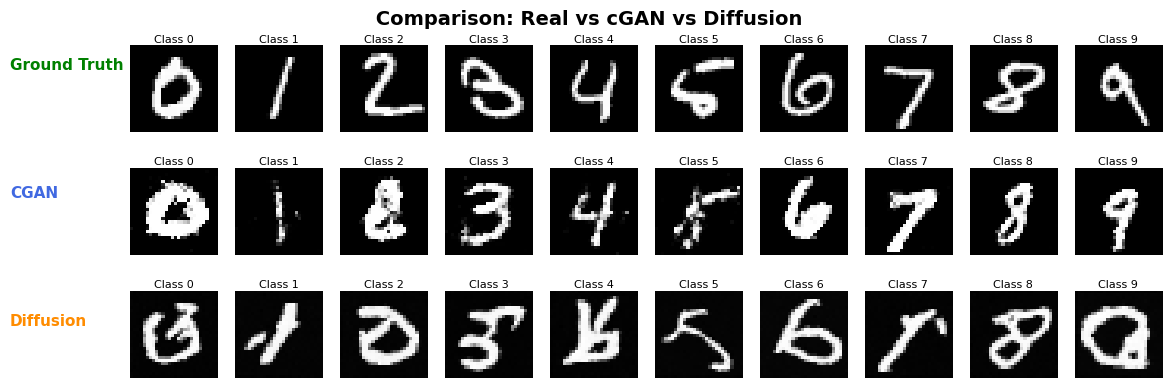

In [39]:
# ToDo: Plot evaluation image using `plot_real_cgan_diffusion`

plot_real_cgan_diffusion(
    real_imgs=real_imgs,
    cgan_imgs=cgan_imgs,
    diff_imgs=diff_imgs,
    n_classes=10
)

In [40]:

fid = FrechetInceptionDistance(normalize=True).to(device)
fid.reset()

In [41]:
torch.cuda.empty_cache()

In [42]:
# ToDo: Choose a subset of images to run the evaluation on - yeild (real_subset, cgan_subset, diff_subset)

num_fid_samples = 1000
samples_per_class = num_fid_samples // num_classes
diffusion_batch_size = 100

# Load a balanced subset of real MNIST images
fid_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_test = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=fid_transform
)

real_images_list = []

for class_id in range(num_classes):
    class_count = 0

    for image, label in mnist_test:
        if label == class_id:
            real_images_list.append(image)
            class_count += 1

        if class_count == samples_per_class:
            break

real_subset = torch.stack(real_images_list)


# Generate a balanced subset of cGAN images
cgan_images_list = []

cgan_gen.eval()

with torch.no_grad():
    for class_id in range(num_classes):
        class_labels = torch.full(
            (samples_per_class,),
            class_id,
            dtype=torch.long,
            device=device
        )

        noise = torch.randn(
            samples_per_class,
            100,
            device=device
        )

        generated_images = cgan_gen(
            noise,
            class_labels
        )

        cgan_images_list.append(generated_images.cpu())

cgan_subset = torch.cat(cgan_images_list, dim=0)


# Generate a balanced subset of Diffusion images
diffusion_images_list = []

diff_model.eval()

for start_idx in tqdm(
    range(0, num_fid_samples, diffusion_batch_size),
    desc="Generating Diffusion samples"
):
    current_batch_size = min(
        diffusion_batch_size,
        num_fid_samples - start_idx
    )

    batch_labels = torch.tensor(
        [
            index % num_classes
            for index in range(
                start_idx,
                start_idx + current_batch_size
            )
        ],
        dtype=torch.long,
        device=device
    )

    generated_images, generated_labels = sample_images(
        model=diff_model,
        device=device,
        num_samples=current_batch_size,
        num_classes=num_classes,
        img_size=(1, 28, 28),
        timesteps=200,
        class_labels=batch_labels
    )

    diffusion_images_list.append(generated_images.cpu())

diff_subset = torch.cat(diffusion_images_list, dim=0)


# Verify that all subsets have matching shapes
print(f"Real subset shape: {real_subset.shape}")
print(f"cGAN subset shape: {cgan_subset.shape}")
print(f"Diffusion subset shape: {diff_subset.shape}")

assert real_subset.shape == cgan_subset.shape
assert real_subset.shape == diff_subset.shape

print("All FID subsets have matching shapes.")

Generating Diffusion samples: 100%|██████████| 10/10 [00:57<00:00,  5.72s/it]

Real subset shape: torch.Size([1000, 1, 28, 28])
cGAN subset shape: torch.Size([1000, 1, 28, 28])
Diffusion subset shape: torch.Size([1000, 1, 28, 28])
All FID subsets have matching shapes.


In [43]:
# ToDo: Compute cGAN FID & Diffusion FID

cgan_fid = compute_fid(
    real_imgs=real_subset,
    fake_imgs=cgan_subset,
    device=device,
    batch_size=128
)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

diff_fid = compute_fid(
    real_imgs=real_subset,
    fake_imgs=diff_subset,
    device=device,
    batch_size=128
)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"cGAN FID: {cgan_fid:.2f}")
print(f"Diffusion FID: {diff_fid:.2f}")

FID fake: 100%|██████████| 8/8 [00:03<00:00,  2.01it/s]


cGAN FID: 58.47
Diffusion FID: 46.63


In [52]:
# ToDO: Give a brief analysis of the FID score

fid_difference = abs(cgan_fid - diff_fid)

print(
    f"The cGAN achieved an FID score of {cgan_fid:.2f}, while the "
    f"Conditional Diffusion Model achieved an FID score of {diff_fid:.2f}."
)

print(
    f"The Conditional Diffusion Model achieved the lower FID score by "
    f"{fid_difference:.2f} points. This indicates that the distribution "
    "of the Diffusion-generated images is statistically closer to the "
    "real MNIST image distribution."
)

print(
    "Based on the FID results, the Conditional Diffusion Model achieved "
    "better overall generative performance than the cGAN in terms of the "
    "combined image fidelity and diversity represented by this metric."
)

print(
    "However, FID does not directly measure whether each generated digit "
    "correctly matches its requested class label. Therefore, the FID scores "
    "should be interpreted together with the visual comparison and the "
    "downstream classifier accuracy."
)

The cGAN achieved an FID score of 58.47, while the Conditional Diffusion Model achieved an FID score of 46.63.
The Conditional Diffusion Model achieved the lower FID score by 11.84 points. This indicates that the distribution of the Diffusion-generated images is statistically closer to the real MNIST image distribution.
Based on the FID results, the Conditional Diffusion Model achieved better overall generative performance than the cGAN in terms of the combined image fidelity and diversity represented by this metric.
However, FID does not directly measure whether each generated digit correctly matches its requested class label. Therefore, the FID scores should be interpreted together with the visual comparison and the downstream classifier accuracy.


### Utility Evaluation (Classifier)

We’ll train a simple CNN classifier on synthetic data from each model,  
then test it on real MNIST data.

If synthetic data are realistic and diverse, the classifier should generalize well to real digits.

In [45]:
cgan_imgs, cgan_labels = generate_conditioned_samples_cgan(cgan_gen, device=device, n_classes=10)
diff_imgs, diff_labels = generate_conditioned_samples_diffusion(
    diff_model, device=device, n_classes=10, timesteps=200
)


In [46]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [47]:
real_data = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

In [48]:
def normalize_synthetic(imgs):
    imgs = imgs.clone()
    imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())  # [0,1]
    imgs = imgs * 2 - 1  # [-1,1]
    return imgs

cgan_imgs = normalize_synthetic(cgan_imgs)
diff_imgs = normalize_synthetic(diff_imgs)

print("Unique labels in CGAN:", torch.unique(cgan_labels))
print("Unique labels in Diffusion:", torch.unique(diff_labels))

Unique labels in CGAN: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Unique labels in Diffusion: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [49]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_classifier(model, loader, epochs=3):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = criterion(preds, labels)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss = {total_loss / len(loader):.4f}")
    return model

In [50]:
cgan_ds = TensorDataset(cgan_imgs, cgan_labels)
diff_ds = TensorDataset(diff_imgs, diff_labels)


cgan_loader = DataLoader(cgan_ds, batch_size=128, shuffle=True)
diff_loader = DataLoader(diff_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(real_data, batch_size=256, shuffle=False)

def test_accuracy(model, loader):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            correct += (preds.argmax(1) == labels).sum().item()
            total += len(labels)
    return correct / total

In [51]:

cnn_cgan = train_classifier(SimpleCNN().to(device), cgan_loader, epochs=20)
cnn_diff = train_classifier(SimpleCNN().to(device), diff_loader, epochs=20)

cgan_acc = test_accuracy(cnn_cgan, test_loader)
diff_acc = test_accuracy(cnn_diff, test_loader)

print(f"Classifier trained on cGAN data → Test accuracy: {cgan_acc:.3f}")
print(f"Classifier trained on Diffusion data → Test accuracy: {diff_acc:.3f}")

Epoch 1: loss = 2.3049
Epoch 2: loss = 2.2449
Epoch 3: loss = 2.1388
Epoch 4: loss = 1.9667
Epoch 5: loss = 1.7237
Epoch 6: loss = 1.4051
Epoch 7: loss = 1.0359
Epoch 8: loss = 0.6623
Epoch 9: loss = 0.3578
Epoch 10: loss = 0.1728
Epoch 11: loss = 0.0679
Epoch 12: loss = 0.0232
Epoch 13: loss = 0.0087
Epoch 14: loss = 0.0032
Epoch 15: loss = 0.0010
Epoch 16: loss = 0.0003
Epoch 17: loss = 0.0001
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Epoch 1: loss = 2.3036
Epoch 2: loss = 2.2059
Epoch 3: loss = 2.0505
Epoch 4: loss = 1.8156
Epoch 5: loss = 1.5019
Epoch 6: loss = 1.1126
Epoch 7: loss = 0.7023
Epoch 8: loss = 0.3573
Epoch 9: loss = 0.1445
Epoch 10: loss = 0.0491
Epoch 11: loss = 0.0143
Epoch 12: loss = 0.0045
Epoch 13: loss = 0.0013
Epoch 14: loss = 0.0004
Epoch 15: loss = 0.0001
Epoch 16: loss = 0.0000
Epoch 17: loss = 0.0000
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Classifier trained on cGAN data → Test accuracy: 0.498
Cla

## Downstream Classification Results

The classifier trained exclusively on cGAN-generated images achieved a test accuracy of **49.8%** on the real MNIST test set. In comparison, the classifier trained exclusively on Diffusion-generated images achieved a test accuracy of **18.0%**.

These results show that the cGAN-generated samples provided substantially greater downstream utility than the Diffusion-generated samples. The cGAN-based classifier outperformed the Diffusion-based classifier by **31.8 percentage points**.

Although the training loss decreased to almost zero for both classifiers, their accuracy on real MNIST images remained considerably lower. This indicates that the classifiers overfitted to the synthetic training images and did not generalize sufficiently well to real handwritten digits. The results therefore suggest a remaining distribution gap between the synthetic images and the real MNIST dataset.

The cGAN achieved the stronger synthetic-data utility in this experiment because its generated images transferred more effectively to the real classification task. In contrast, the Diffusion Model achieved the better FID score, indicating greater statistical similarity to the real image distribution, but its generated data were less useful for training the downstream classifier.

Overall, the evaluation shows that the two metrics assess different aspects of generative performance:

- The **Diffusion Model** achieved better image-distribution similarity according to FID.
- The **cGAN** provided better practical utility according to downstream classifier accuracy.
- Neither model achieved sufficient downstream accuracy to eliminate the observed gap between synthetic and real handwritten digits.